In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, classification_report, ConfusionMatrixDisplay
import matplotlib.ticker as mticker
from sklearn import metrics

Dataset: <br>
League - Serie A <br>
Year(s) - 2021-25 <br>

In [49]:
# Data Collection
# Import data from csv file
df = pd.read_csv('Final_SerieA_DataSet_All.csv')
# df

In [50]:
# Pre-Processing 
# Create new column Match_Outcome using Home_Score and Away_Score
filtered = df.loc[df['Time']=='FT']
# filtered

conditions = [
    (filtered['Home_Score'] > filtered['Away_Score']),
    (filtered['Away_Score'] > filtered['Home_Score']),
    (filtered['Home_Score'] == filtered['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']

filtered['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')

# filtered

match_outcome_dict = dict(zip(filtered['Game_ID'].values, filtered['Match_Outcomes'].values))
# match_outcome_dict

df['Match_Outcomes'] = df['Game_ID'].map(match_outcome_dict) # assigns the new col

df.head()

C:\Users\matth\AppData\Local\Temp\ipykernel_32088\473369177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')


,Game_ID,Season,Matchweek,Game_Type,Time,Team,Home_Score,Away_Score,Home_Red_Count,Away_Red_Count,...,Away_Off_Sub_Count,Away_Def_Sub_Count,Match_URL,Event_Type,Player_1,Pos_1,Player_2,Pos_2,Note,Match_Outcomes
0,420210101,2021,1,League,32,Away,0,1,0,0,...,0,0,https://fbref.com/en/matches/81074285/Hellas-V...,Goal,Giacomo Raspadori,AM,NaN,NaN,Goal,Away_Win
1,420210101,2021,1,League,45+1,Home,0,1,1,0,...,0,0,https://fbref.com/en/matches/81074285/Hellas-V...,Red Card,Miguel Veloso,CM,NaN,NaN,Red Card,Away_Win
2,420210101,2021,1,League,46,Home,0,1,1,0,...,0,0,https://fbref.com/en/matches/81074285/Hellas-V...,Substitution,Nikola Kalinić,FW,Matteo Cancellieri,RM,Defensive Sub,Away_Win
3,420210101,2021,1,League,51,Away,0,2,1,0,...,0,0,https://fbref.com/en/matches/81074285/Hellas-V...,Goal,Filip Đuričić,RW,NaN,NaN,Goal,Away_Win
4,420210101,2021,1,League,54,Home,0,2,1,0,...,0,0,https://fbref.com/en/matches/81074285/Hellas-V...,Substitution,Martin Hongla,CM,Adrien Tameze,CM,Neutral Sub,Away_Win


In [51]:
# Pre-Processing (cont.)
# Convert Time column to usable format, 
# Note: times like 45+4 become 49, which intersect with the normal 49min datapoint (one before and after halftime), will see a small discrepancy here
#       times 90+5 become 95 with no issues
#       times FT are dropped as they directly relate the target result, ruining the model

df_filtered = df[df['Time']!='FT'] # drops 'FT' times
df_filtered['Time'] = df_filtered['Time'].apply(eval) # evals expression, ex: 45+3->48


C:\Users\matth\AppData\Local\Temp\ipykernel_32088\715974466.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Time'] = df_filtered['Time'].apply(eval) # evals expression, ex: 45+3->48


In [52]:
# Pre-Processing (cont.)
# Isolate league games, cup games operate under different rule formats and have different strategies

df_filtered = df_filtered[df_filtered['Matchweek']!='Cup'] # drops 'Cup' games

In [53]:
X = df_filtered.loc[:, ['Time', 'Home_Score', 'Away_Score', 'Home_Red_Count', 'Away_Red_Count', 
               'Home_Off_Sub_Count', 'Home_Def_Sub_Count', 'Away_Off_Sub_Count', 'Away_Def_Sub_Count']]
X.shape

y = df_filtered.loc[:,'Match_Outcomes'].values
y

# Train/Test Split with 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2)

Find best k value

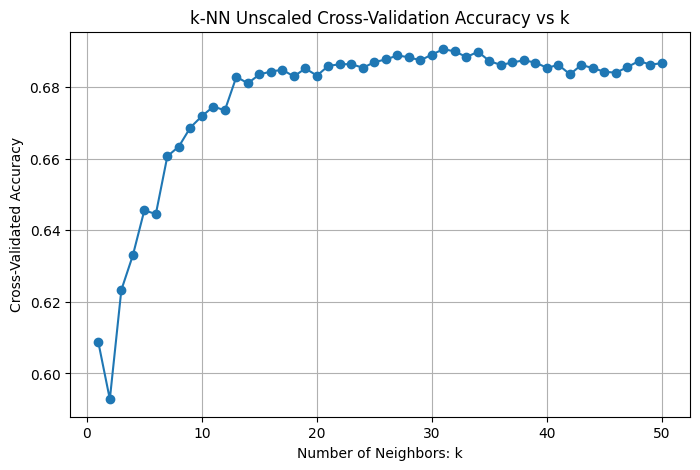

Best k from cross-validation: 31


In [54]:
k_range = range(1, 51)
cv_scores = []

# Evaluate each k using 5-fold cross-validation
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot accuracy vs. k
plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, marker='o')
plt.title("k-NN Unscaled Cross-Validation Accuracy vs k")
plt.xlabel("Number of Neighbors: k")
plt.ylabel("Cross-Validated Accuracy")
plt.grid(True)
plt.show()

# Best k
best_k = k_range[np.argmax(cv_scores)]
print(f"Best k from cross-validation: {best_k}")

In [55]:
# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=0, stratify=y
)

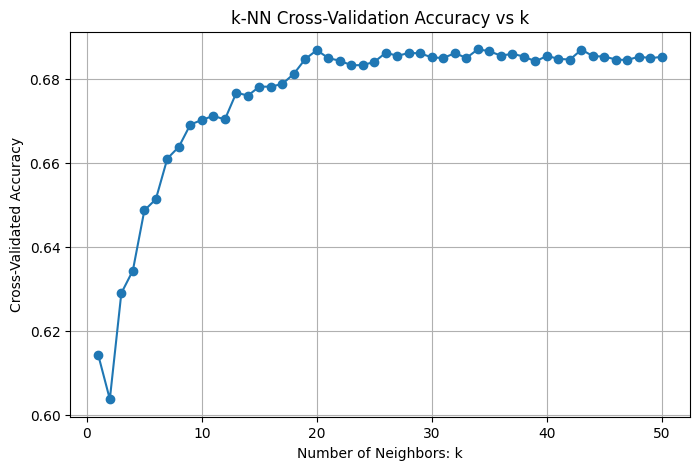

Best k from cross-validation: 34


In [56]:
# Range of k values to try
k_range = range(1, 51)
cv_scores = []

# Evaluate each k using 5-fold cross-validation
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot accuracy vs. k
plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, marker='o')
plt.title("k-NN Cross-Validation Accuracy vs k")
plt.xlabel("Number of Neighbors: k")
plt.ylabel("Cross-Validated Accuracy")
plt.grid(True)
plt.show()

# Best k
best_k = k_range[np.argmax(cv_scores)]
print(f"Best k from cross-validation: {best_k}")

In [57]:
# k = n_neighbors = 31 -> from best no_scaling

pipeline_no_scaling2 = Pipeline([('knn', KNeighborsClassifier(n_neighbors=31))])

pipeline_with_scaling2 = Pipeline([('scaler', StandardScaler()),
                                  ('knn', KNeighborsClassifier(n_neighbors=31))])

pipeline_no_scaling2.fit(X_train, y_train)

pipeline_with_scaling2.fit(X_train, y_train)

,steps,"[('scaler', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,31
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [58]:
print("k-NN without scaling:")
# Write your code here.
train_acc_no_scaling2 = pipeline_no_scaling2.score(X_train, y_train)
test_acc_no_scaling2 = pipeline_no_scaling2.score(X_test, y_test)
print(f'Training Accuracy: {train_acc_no_scaling2}\nTest Accuracy: {test_acc_no_scaling2}')

print("\nk-NN with StandardScaler:")
# Write your code here.
train_acc_scaling2 = pipeline_with_scaling2.score(X_train, y_train)
test_acc_scaling2 = pipeline_with_scaling2.score(X_test, y_test)
print(f'Training Accuracy: {train_acc_scaling2}\nTest Accuracy: {test_acc_scaling2}')

k-NN without scaling:
Training Accuracy: 0.727726154687073
Test Accuracy: 0.7079234972677596

k-NN with StandardScaler:
Training Accuracy: 0.727384531292703
Test Accuracy: 0.7079234972677596


Confusion Matrix from pipeline_no_scaling:


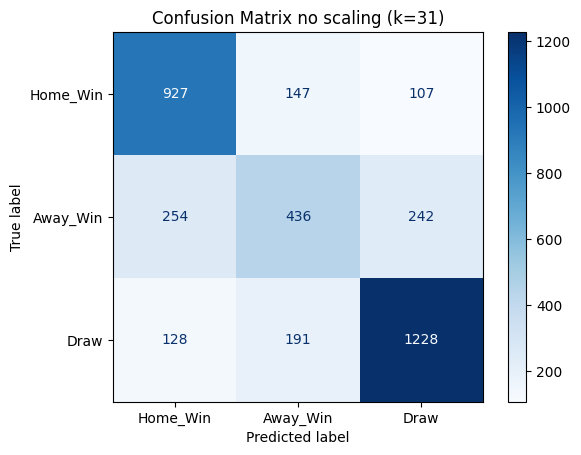

[[ 927  147  107]
 [ 254  436  242]
 [ 128  191 1228]]
Classification Report:
              precision    recall  f1-score   support

    Home_Win       0.71      0.78      0.74      1181
    Away_Win       0.56      0.47      0.51       932
        Draw       0.78      0.79      0.79      1547

    accuracy                           0.71      3660
   macro avg       0.68      0.68      0.68      3660
weighted avg       0.70      0.71      0.70      3660

Confusion Matrix from pipeline_with_scaling:


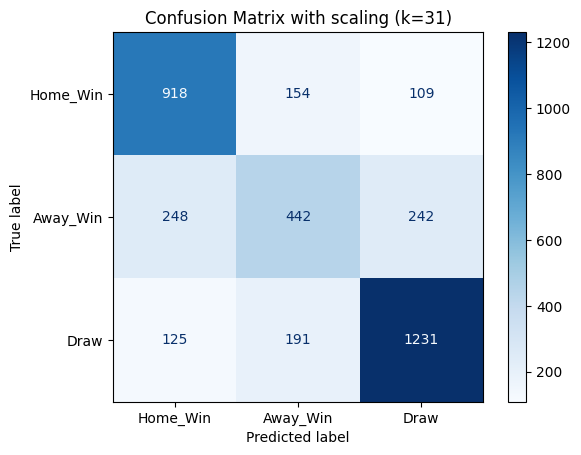

[[ 918  154  109]
 [ 248  442  242]
 [ 125  191 1231]]
Classification Report:
              precision    recall  f1-score   support

    Home_Win       0.71      0.78      0.74      1181
    Away_Win       0.56      0.47      0.51       932
        Draw       0.78      0.80      0.79      1547

    accuracy                           0.71      3660
   macro avg       0.68      0.68      0.68      3660
weighted avg       0.70      0.71      0.70      3660



In [59]:
y_pred = pipeline_no_scaling2.predict(X_test)
y_pred2 = pipeline_with_scaling2.predict(X_test)

# 4. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm2 = confusion_matrix(y_test, y_pred2)
print('Confusion Matrix from pipeline_no_scaling:')
# Confusion Matrix no Scaling
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Home_Win", "Away_Win", "Draw"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix no scaling (k={31})")
plt.grid(False)
plt.show()
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Home_Win", "Away_Win", "Draw"]))

print('Confusion Matrix from pipeline_with_scaling:')
# Confusion Matrix no Scaling
disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["Home_Win", "Away_Win", "Draw"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix with scaling (k={31})")
plt.grid(False)
plt.show()
print(cm2)

print("Classification Report:")
print(classification_report(y_test, y_pred2, target_names=["Home_Win", "Away_Win", "Draw"]))

In [60]:
# k = n_neighbors = 34 -> from best with_scaling

pipeline_no_scaling2 = Pipeline([('knn', KNeighborsClassifier(n_neighbors=34))])

pipeline_with_scaling2 = Pipeline([('scaler', StandardScaler()),
                                  ('knn', KNeighborsClassifier(n_neighbors=34))])

pipeline_no_scaling2.fit(X_train, y_train)

pipeline_with_scaling2.fit(X_train, y_train)

,steps,"[('scaler', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,34
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [61]:
print("k-NN without scaling:")
# Write your code here.
train_acc_no_scaling2 = pipeline_no_scaling2.score(X_train, y_train)
test_acc_no_scaling2 = pipeline_no_scaling2.score(X_test, y_test)
print(f'Training Accuracy: {train_acc_no_scaling2}\nTest Accuracy: {test_acc_no_scaling2}')

print("\nk-NN with StandardScaler:")
# Write your code here.
train_acc_scaling2 = pipeline_with_scaling2.score(X_train, y_train)
test_acc_scaling2 = pipeline_with_scaling2.score(X_test, y_test)
print(f'Training Accuracy: {train_acc_scaling2}\nTest Accuracy: {test_acc_scaling2}')

k-NN without scaling:
Training Accuracy: 0.7261546870729707
Test Accuracy: 0.7071038251366121

k-NN with StandardScaler:
Training Accuracy: 0.7258813883574747
Test Accuracy: 0.7060109289617487


Confusion Matrix from pipeline_no_scaling:


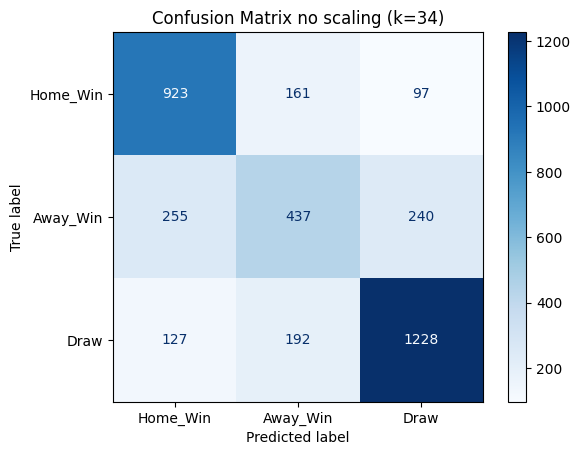

[[ 923  161   97]
 [ 255  437  240]
 [ 127  192 1228]]
Classification Report:
              precision    recall  f1-score   support

    Home_Win       0.71      0.78      0.74      1181
    Away_Win       0.55      0.47      0.51       932
        Draw       0.78      0.79      0.79      1547

    accuracy                           0.71      3660
   macro avg       0.68      0.68      0.68      3660
weighted avg       0.70      0.71      0.70      3660

Confusion Matrix from pipeline_with_scaling:


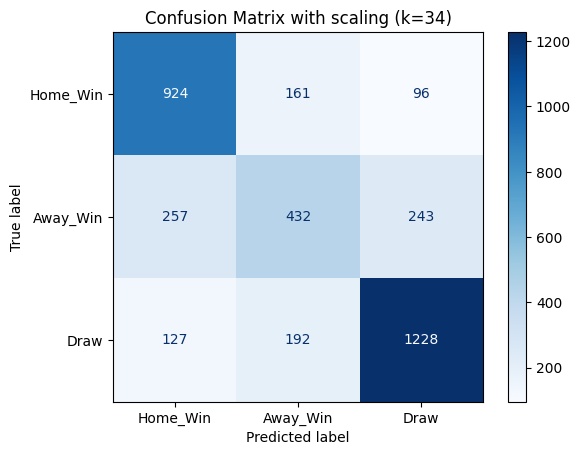

[[ 924  161   96]
 [ 257  432  243]
 [ 127  192 1228]]
Classification Report:
              precision    recall  f1-score   support

    Home_Win       0.71      0.78      0.74      1181
    Away_Win       0.55      0.46      0.50       932
        Draw       0.78      0.79      0.79      1547

    accuracy                           0.71      3660
   macro avg       0.68      0.68      0.68      3660
weighted avg       0.70      0.71      0.70      3660



In [62]:
y_pred = pipeline_no_scaling2.predict(X_test)
y_pred2 = pipeline_with_scaling2.predict(X_test)

# 4. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm2 = confusion_matrix(y_test, y_pred2)
print('Confusion Matrix from pipeline_no_scaling:')
# Confusion Matrix no Scaling
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Home_Win", "Away_Win", "Draw"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix no scaling (k={34})")
plt.grid(False)
plt.show()
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Home_Win", "Away_Win", "Draw"]))

print('Confusion Matrix from pipeline_with_scaling:')
# Confusion Matrix no Scaling
disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["Home_Win", "Away_Win", "Draw"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix with scaling (k={34})")
plt.grid(False)
plt.show()
print(cm2)

print("Classification Report:")
print(classification_report(y_test, y_pred2, target_names=["Home_Win", "Away_Win", "Draw"]))

In [63]:
# k = n_neighbors = 5 -> worse num for comparison

pipeline_no_scaling2 = Pipeline([('knn', KNeighborsClassifier(n_neighbors=5))])

pipeline_with_scaling2 = Pipeline([('scaler', StandardScaler()),
                                  ('knn', KNeighborsClassifier(n_neighbors=5))])

pipeline_no_scaling2.fit(X_train, y_train)

pipeline_with_scaling2.fit(X_train, y_train)

,steps,"[('scaler', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [66]:
print("k-NN without scaling:")
# Write your code here.
train_acc_no_scaling2 = pipeline_no_scaling2.score(X_train, y_train)
test_acc_no_scaling2 = pipeline_no_scaling2.score(X_test, y_test)
print(f'Training Accuracy: {train_acc_no_scaling2}\nTest Accuracy: {test_acc_no_scaling2}')

print("\nk-NN with StandardScaler:")
# Write your code here.
train_acc_scaling2 = pipeline_with_scaling2.score(X_train, y_train)
test_acc_scaling2 = pipeline_with_scaling2.score(X_test, y_test)
print(f'Training Accuracy: {train_acc_scaling2}\nTest Accuracy: {test_acc_scaling2}')

k-NN without scaling:
Training Accuracy: 0.7620934681606997
Test Accuracy: 0.6989071038251367

k-NN with StandardScaler:
Training Accuracy: 0.7621617928395736
Test Accuracy: 0.7


Confusion Matrix from pipeline_no_scaling:


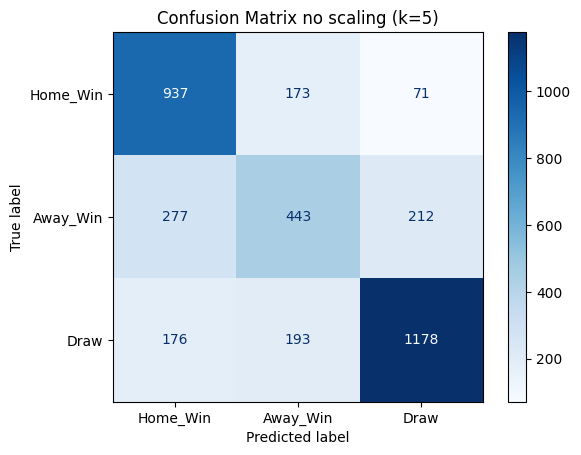

[[ 937  173   71]
 [ 277  443  212]
 [ 176  193 1178]]
Classification Report:
              precision    recall  f1-score   support

    Home_Win       0.67      0.79      0.73      1181
    Away_Win       0.55      0.48      0.51       932
        Draw       0.81      0.76      0.78      1547

    accuracy                           0.70      3660
   macro avg       0.68      0.68      0.67      3660
weighted avg       0.70      0.70      0.70      3660

Confusion Matrix from pipeline_with_scaling:


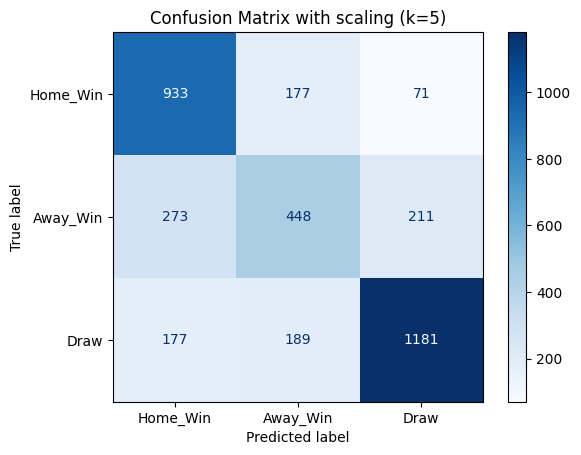

[[ 933  177   71]
 [ 273  448  211]
 [ 177  189 1181]]
Classification Report:
              precision    recall  f1-score   support

    Home_Win       0.67      0.79      0.73      1181
    Away_Win       0.55      0.48      0.51       932
        Draw       0.81      0.76      0.78      1547

    accuracy                           0.70      3660
   macro avg       0.68      0.68      0.68      3660
weighted avg       0.70      0.70      0.70      3660



In [67]:
y_pred = pipeline_no_scaling2.predict(X_test)
y_pred2 = pipeline_with_scaling2.predict(X_test)

# 4. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm2 = confusion_matrix(y_test, y_pred2)
print('Confusion Matrix from pipeline_no_scaling:')
# Confusion Matrix no Scaling
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Home_Win", "Away_Win", "Draw"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix no scaling (k={5})")
plt.grid(False)
plt.show()
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Home_Win", "Away_Win", "Draw"]))

print('Confusion Matrix from pipeline_with_scaling:')
# Confusion Matrix no Scaling
disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["Home_Win", "Away_Win", "Draw"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix with scaling (k={5})")
plt.grid(False)
plt.show()
print(cm2)

print("Classification Report:")
print(classification_report(y_test, y_pred2, target_names=["Home_Win", "Away_Win", "Draw"]))

In [68]:
# k = n_neighbors = 21 -> worse num for comparison

pipeline_no_scaling2 = Pipeline([('knn', KNeighborsClassifier(n_neighbors=21))])

pipeline_with_scaling2 = Pipeline([('scaler', StandardScaler()),
                                  ('knn', KNeighborsClassifier(n_neighbors=21))])

pipeline_no_scaling2.fit(X_train, y_train)

pipeline_with_scaling2.fit(X_train, y_train)

,steps,"[('scaler', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,21
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [69]:
print("k-NN without scaling:")
# Write your code here.
train_acc_no_scaling2 = pipeline_no_scaling2.score(X_train, y_train)
test_acc_no_scaling2 = pipeline_no_scaling2.score(X_test, y_test)
print(f'Training Accuracy: {train_acc_no_scaling2}\nTest Accuracy: {test_acc_no_scaling2}')

print("\nk-NN with StandardScaler:")
# Write your code here.
train_acc_scaling2 = pipeline_with_scaling2.score(X_train, y_train)
test_acc_scaling2 = pipeline_with_scaling2.score(X_test, y_test)
print(f'Training Accuracy: {train_acc_scaling2}\nTest Accuracy: {test_acc_scaling2}')

k-NN without scaling:
Training Accuracy: 0.7398879475266467
Test Accuracy: 0.7128415300546448

k-NN with StandardScaler:
Training Accuracy: 0.7392730254167805
Test Accuracy: 0.7139344262295082


Confusion Matrix from pipeline_no_scaling:


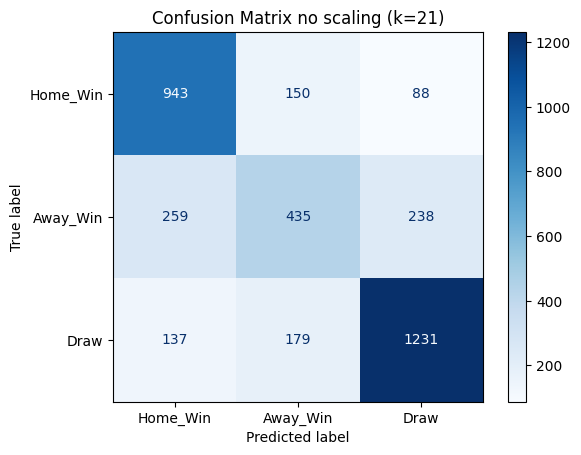

[[ 943  150   88]
 [ 259  435  238]
 [ 137  179 1231]]
Classification Report:
              precision    recall  f1-score   support

    Home_Win       0.70      0.80      0.75      1181
    Away_Win       0.57      0.47      0.51       932
        Draw       0.79      0.80      0.79      1547

    accuracy                           0.71      3660
   macro avg       0.69      0.69      0.68      3660
weighted avg       0.71      0.71      0.71      3660

Confusion Matrix from pipeline_with_scaling:


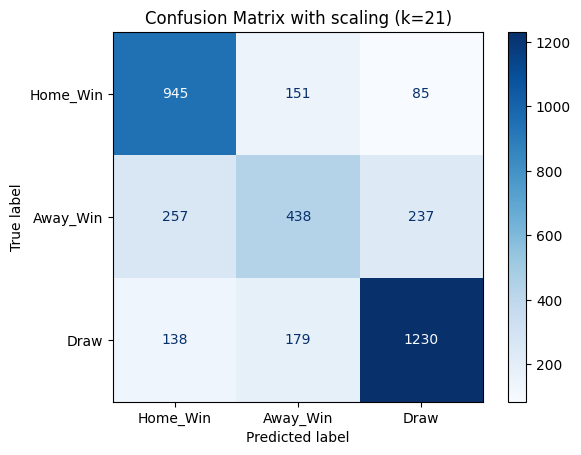

[[ 945  151   85]
 [ 257  438  237]
 [ 138  179 1230]]
Classification Report:
              precision    recall  f1-score   support

    Home_Win       0.71      0.80      0.75      1181
    Away_Win       0.57      0.47      0.52       932
        Draw       0.79      0.80      0.79      1547

    accuracy                           0.71      3660
   macro avg       0.69      0.69      0.69      3660
weighted avg       0.71      0.71      0.71      3660



In [70]:
y_pred = pipeline_no_scaling2.predict(X_test)
y_pred2 = pipeline_with_scaling2.predict(X_test)

# 4. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm2 = confusion_matrix(y_test, y_pred2)
print('Confusion Matrix from pipeline_no_scaling:')
# Confusion Matrix no Scaling
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Home_Win", "Away_Win", "Draw"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix no scaling (k={21})")
plt.grid(False)
plt.show()
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Home_Win", "Away_Win", "Draw"]))

print('Confusion Matrix from pipeline_with_scaling:')
# Confusion Matrix no Scaling
disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["Home_Win", "Away_Win", "Draw"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix with scaling (k={21})")
plt.grid(False)
plt.show()
print(cm2)

print("Classification Report:")
print(classification_report(y_test, y_pred2, target_names=["Home_Win", "Away_Win", "Draw"]))

<h3>Feature Selection</h3>
<br>
All feature's vs time

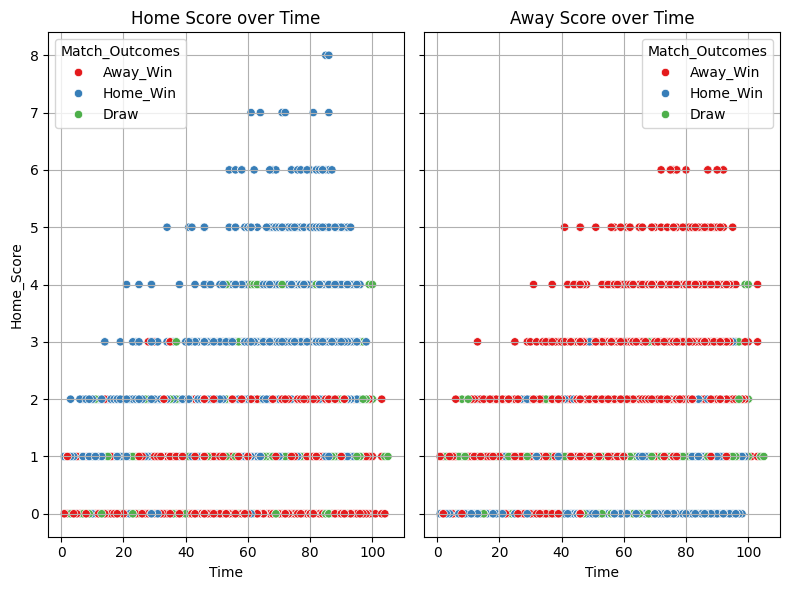

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

# Plot 1 (Left side)
sns.scatterplot(data=df_filtered, x="Time", y="Home_Score", hue="Match_Outcomes", palette="Set1", ax=axes[0])
axes[0].set_title("Home Score over Time")
axes[0].grid(True)

# Plot 2 (Right side)
sns.scatterplot(data=df_filtered, x="Time", y="Away_Score", hue="Match_Outcomes", palette="Set1", ax=axes[1])
axes[1].set_title("Away Score over Time")
axes[1].grid(True)

plt.tight_layout()
plt.show()

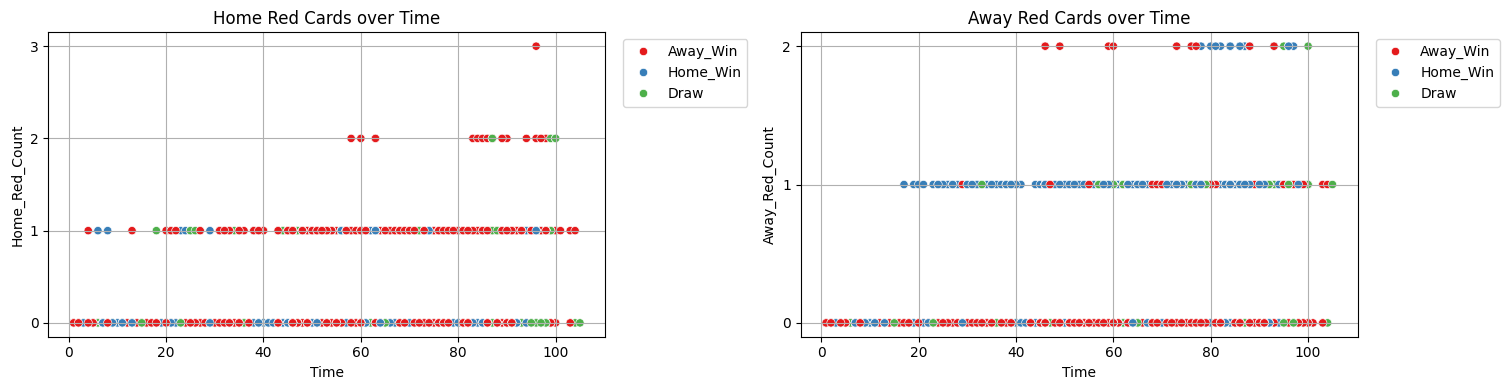

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=False)

# Define a common formatter for integer display
integer_formatter = mticker.FormatStrFormatter('%d')

# Plot 1 (Left side)
sns.scatterplot(data=df_filtered, x="Time", y="Home_Red_Count", hue="Match_Outcomes", palette="Set1", ax=axes[0])
axes[0].set_title("Home Red Cards over Time")
axes[0].grid(True)
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set y-axis to integers
axes[0].yaxis.set_major_formatter(integer_formatter)
axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# Plot 2 (Right side)
sns.scatterplot(data=df_filtered, x="Time", y="Away_Red_Count", hue="Match_Outcomes", palette="Set1", ax=axes[1])
axes[1].set_title("Away Red Cards over Time")
axes[1].grid(True)
axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set y-axis to integers
axes[1].yaxis.set_major_formatter(integer_formatter)
axes[1].legend(loc='upper left', bbox_to_anchor=(1.02, 1))


plt.tight_layout(rect=[0, 0, 0.95, 1]) # Adjust layout to prevent the external legend from being cut off
plt.show()

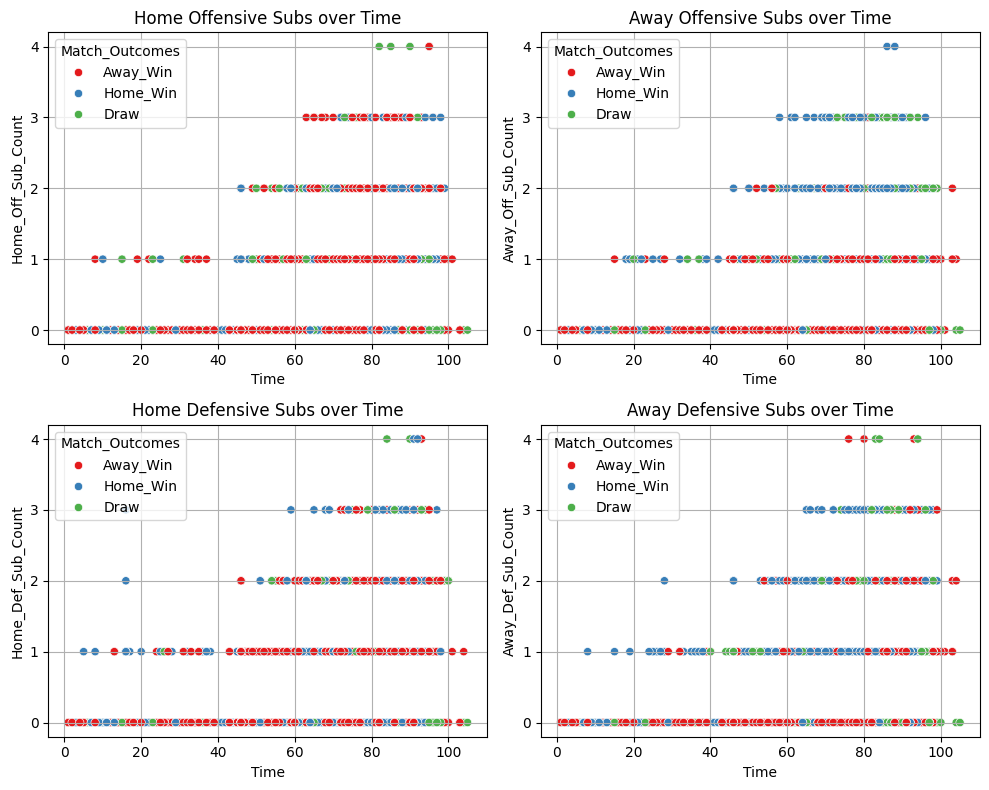

In [73]:
# Create a single figure with 2 rows and 2 columns (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=False)

# Define a common formatter for integer display
integer_formatter = mticker.FormatStrFormatter('%d')

# Plot 1 (Top Left)
sns.scatterplot(data=df_filtered, x="Time", y="Home_Off_Sub_Count", hue="Match_Outcomes", palette="Set1", ax=axes[0, 0])
axes[0, 0].set_title("Home Offensive Subs over Time")
axes[0, 0].grid(True)
axes[0, 0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set y-axis to integers
axes[0, 0].yaxis.set_major_formatter(integer_formatter)


# Plot 2 (Top Right)
sns.scatterplot(data=df_filtered, x="Time", y="Away_Off_Sub_Count", hue="Match_Outcomes", palette="Set1", ax=axes[0, 1])
axes[0, 1].set_title("Away Offensive Subs over Time")
axes[0, 1].grid(True)
axes[0, 1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set y-axis to integers
axes[0, 1].yaxis.set_major_formatter(integer_formatter)

# Plot 3 (Bottom Left) - Corrected Title
sns.scatterplot(data=df_filtered, x="Time", y="Home_Def_Sub_Count", hue="Match_Outcomes", palette="Set1", ax=axes[1, 0])
axes[1, 0].set_title("Home Defensive Subs over Time")
axes[1, 0].grid(True)
axes[1, 0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set y-axis to integers
axes[1, 0].yaxis.set_major_formatter(integer_formatter)

# Plot 4 (Bottom Right) - Corrected Title
sns.scatterplot(data=df_filtered, x="Time", y="Away_Def_Sub_Count", hue="Match_Outcomes", palette="Set1", ax=axes[1, 1])
axes[1, 1].set_title("Away Defensive Subs over Time")
axes[1, 1].grid(True)
axes[1, 1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set y-axis to integers
axes[1, 1].yaxis.set_major_formatter(integer_formatter)

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the single combined figure
plt.show()

Score/RedCards vs Substitutions

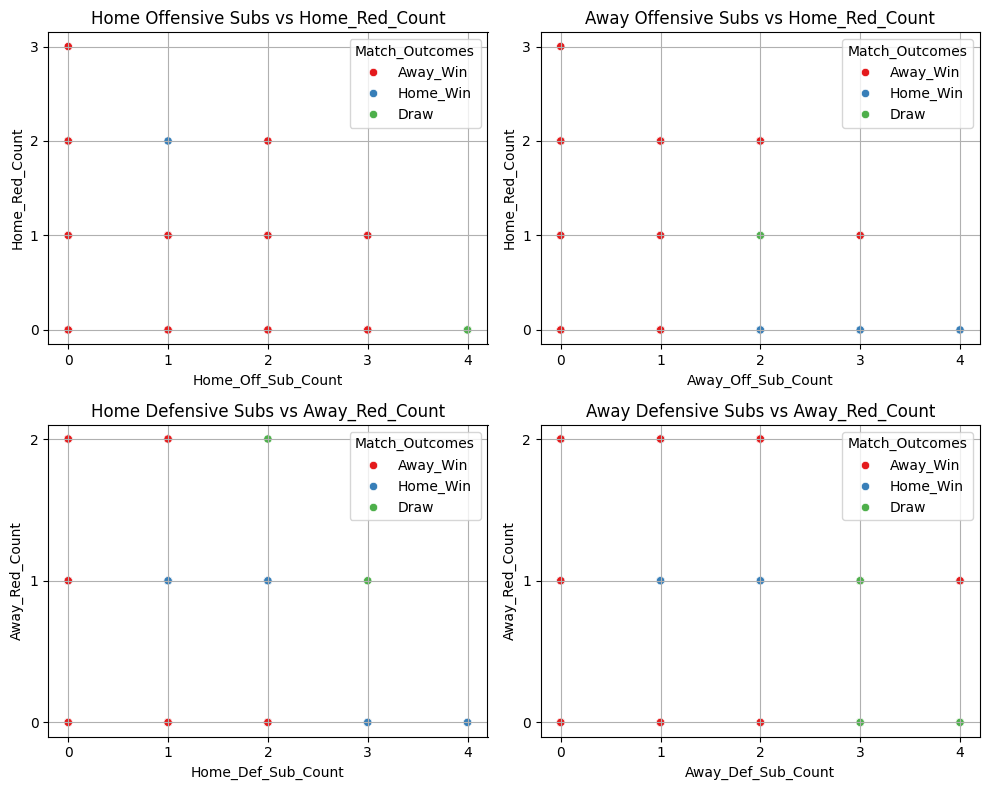

In [74]:
# Create a single figure with 2 rows and 2 columns (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=False)

# Define a common formatter for integer display
integer_formatter = mticker.FormatStrFormatter('%d')

# Plot 1 (Top Left)
sns.scatterplot(data=df_filtered, y="Home_Red_Count", x="Home_Off_Sub_Count", hue="Match_Outcomes", palette="Set1", ax=axes[0, 0])
axes[0, 0].set_title("Home Offensive Subs vs Home_Red_Count")
axes[0, 0].grid(True)
axes[0, 0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set x-axis to integers
axes[0, 0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set y-axis to integers
axes[0, 0].xaxis.set_major_formatter(integer_formatter)
axes[0, 0].yaxis.set_major_formatter(integer_formatter)

# Plot 2 (Top Right)
sns.scatterplot(data=df_filtered, y="Home_Red_Count", x="Away_Off_Sub_Count", hue="Match_Outcomes", palette="Set1", ax=axes[0, 1])
axes[0, 1].set_title("Away Offensive Subs vs Home_Red_Count")
axes[0, 1].grid(True)
axes[0, 1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0, 1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0, 1].xaxis.set_major_formatter(integer_formatter)
axes[0, 1].yaxis.set_major_formatter(integer_formatter)

# Plot 3 (Bottom Left) - Corrected Title
sns.scatterplot(data=df_filtered, y="Away_Red_Count", x="Home_Def_Sub_Count", hue="Match_Outcomes", palette="Set1", ax=axes[1, 0])
axes[1, 0].set_title("Home Defensive Subs vs Away_Red_Count")
axes[1, 0].grid(True)
axes[1, 0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1, 0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1, 0].xaxis.set_major_formatter(integer_formatter)
axes[1, 0].yaxis.set_major_formatter(integer_formatter)

# Plot 4 (Bottom Right) - Corrected Title
sns.scatterplot(data=df_filtered, y="Away_Red_Count", x="Away_Def_Sub_Count", hue="Match_Outcomes", palette="Set1", ax=axes[1, 1])
axes[1, 1].set_title("Away Defensive Subs vs Away_Red_Count")
axes[1, 1].grid(True)
axes[1, 1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1, 1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1, 1].xaxis.set_major_formatter(integer_formatter)
axes[1, 1].yaxis.set_major_formatter(integer_formatter)

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the single combined figure
plt.show()

Score vs Red_Cards

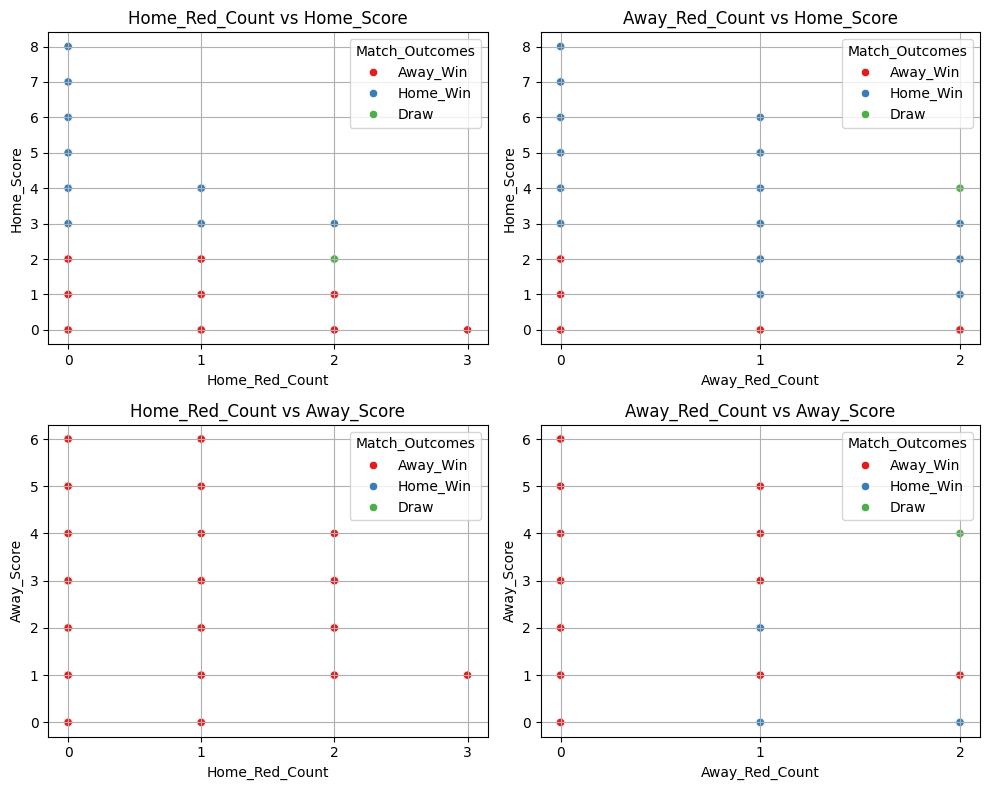

In [75]:
# Create a single figure with 2 rows and 2 columns (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=False)

# Define a common formatter for integer display
integer_formatter = mticker.FormatStrFormatter('%d')

# Plot 1 (Top Left)
sns.scatterplot(data=df_filtered, y="Home_Score", x="Home_Red_Count", hue="Match_Outcomes", palette="Set1", ax=axes[0, 0])
axes[0, 0].set_title("Home_Red_Count vs Home_Score")
axes[0, 0].grid(True)
axes[0, 0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set x-axis to integers
axes[0, 0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set y-axis to integers
axes[0, 0].xaxis.set_major_formatter(integer_formatter)
axes[0, 0].yaxis.set_major_formatter(integer_formatter)

# Plot 2 (Top Right)
sns.scatterplot(data=df_filtered, y="Home_Score", x="Away_Red_Count", hue="Match_Outcomes", palette="Set1", ax=axes[0, 1])
axes[0, 1].set_title("Away_Red_Count vs Home_Score")
axes[0, 1].grid(True)
axes[0, 1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0, 1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0, 1].xaxis.set_major_formatter(integer_formatter)
axes[0, 1].yaxis.set_major_formatter(integer_formatter)

# Plot 3 (Bottom Left) - Corrected Title
sns.scatterplot(data=df_filtered, y="Away_Score", x="Home_Red_Count", hue="Match_Outcomes", palette="Set1", ax=axes[1, 0])
axes[1, 0].set_title("Home_Red_Count vs Away_Score")
axes[1, 0].grid(True)
axes[1, 0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1, 0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1, 0].xaxis.set_major_formatter(integer_formatter)
axes[1, 0].yaxis.set_major_formatter(integer_formatter)

# Plot 4 (Bottom Right) - Corrected Title
sns.scatterplot(data=df_filtered, y="Away_Score", x="Away_Red_Count", hue="Match_Outcomes", palette="Set1", ax=axes[1, 1])
axes[1, 1].set_title("Away_Red_Count vs Away_Score")
axes[1, 1].grid(True)
axes[1, 1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1, 1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1, 1].xaxis.set_major_formatter(integer_formatter)
axes[1, 1].yaxis.set_major_formatter(integer_formatter)

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the single combined figure
plt.show()